# 09 Systematic Market Risk Diagnostics

Use one frozen benchmark and one excess-return alignment for both market-risk diagnostics and Module 12 alpha inference. No live benchmark download or strategy rerun occurs.

Run cells from top to bottom, or choose **Run All** for this notebook only. Each module saves its outputs for the next notebook. Restart the kernel after pulling code changes.


## 1. Imports and saved run


In [1]:
%matplotlib inline
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'research_config.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open Jupyter inside the Pairs_trading repository.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.project_io import OUTPUT_DIR, initialize, load_config, load_frame, save_frame, save_json

cfg = load_config()


## 2. Full period market regression

HAC uses the configured lag count. Risk-free conversion uses the prior-session annual-effective rate.


In [2]:
from src.research_validation import aligned_returns, market_regression
from src.project_io import read_series
import json

aligned = aligned_returns(
    load_frame("equity_curve"),
    read_series(OUTPUT_DIR / "inputs/benchmark.parquet"),
    read_series(OUTPUT_DIR / "inputs/rates.parquet"),
)
save_frame("market_alignment", aligned)
market_alpha = market_regression(aligned, cfg.hac_lags)
save_json("market_alpha", market_alpha)
display(pd.Series(market_alpha))
display(aligned.head())


status                                                       ok
alpha_daily                                            0.000497
alpha_annualized_simple                                0.125291
alpha_HAC_se                                           0.001058
alpha_t_stat                                           0.469916
alpha_p_value_two_sided                                0.638415
alpha_p_value_one_sided_positive                       0.319207
market_beta                                           -0.135836
r_squared                                              0.002611
n_obs                                                       754
hac_lags                                                      5
rf_convention                       annual_effective_lagged_252
start                                       2022-12-29 00:00:00
end                                         2025-12-31 00:00:00
dtype: object

,strategy_return,market_return,rf_daily,strategy_excess,market_excess
date,,,,,
2022-12-29,-0.000269,0.017461,0.000169,-0.000438,0.017293
2022-12-30,0.000064,-0.002541,0.000167,-0.000103,-0.002708
2023-01-03,-0.003702,-0.004001,0.000166,-0.003867,-0.004166
2023-01-04,0.000007,0.007539,0.000165,-0.000158,0.007374
2023-01-05,-0.011828,-0.011646,0.000171,-0.011999,-0.011816


## 3. Annual and conditional market exposure

Annual and up/down estimates are descriptive subsamples. They do not formally test coefficient equality.


In [3]:
records = []
for year, group in aligned.groupby(aligned.index.year):
    records.append({"sample": str(year), **market_regression(group, cfg.hac_lags)})
for label, group in [
    ("market_up", aligned.loc[aligned.market_return > 0]),
    ("market_down", aligned.loc[aligned.market_return <= 0]),
]:
    records.append({"sample": label, **market_regression(group, cfg.hac_lags)})
market_subsamples = pd.DataFrame(records)
save_frame("market_subsamples", market_subsamples)
display(market_subsamples)


,sample,status,n_obs,alpha_daily,alpha_annualized_simple,alpha_HAC_se,alpha_t_stat,alpha_p_value_two_sided,alpha_p_value_one_sided_positive,market_beta,r_squared,hac_lags,rf_convention,start,end
0,2022,insufficient_market_variation,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,ok,250,0.001327,0.334388,0.001505,0.881430,0.378085,0.189043,0.134839,0.002399,5.0,annual_effective_lagged_252,2023-01-03 00:00:00,2023-12-29 00:00:00
2,2024,ok,252,0.000819,0.206448,0.001757,0.466207,0.641068,0.320534,0.635317,0.035663,5.0,annual_effective_lagged_252,2024-01-02 00:00:00,2024-12-31 00:00:00
3,2025,ok,250,-0.001119,-0.281951,0.001921,-0.582468,0.560252,0.719874,-0.624562,0.079786,5.0,annual_effective_lagged_252,2025-01-02 00:00:00,2025-12-31 00:00:00
4,market_up,ok,425,-0.000248,-0.062547,0.002294,-0.108175,0.913857,0.543072,0.183006,0.002723,5.0,annual_effective_lagged_252,2022-12-29 00:00:00,2025-12-24 00:00:00
5,market_down,ok,329,-0.006811,-1.716247,0.002500,-2.724689,0.006436,0.996782,-0.965729,0.062812,5.0,annual_effective_lagged_252,2022-12-30 00:00:00,2025-12-31 00:00:00


## 4. Rolling beta and correlation

Rolling estimates are descriptive and require 63 observations.


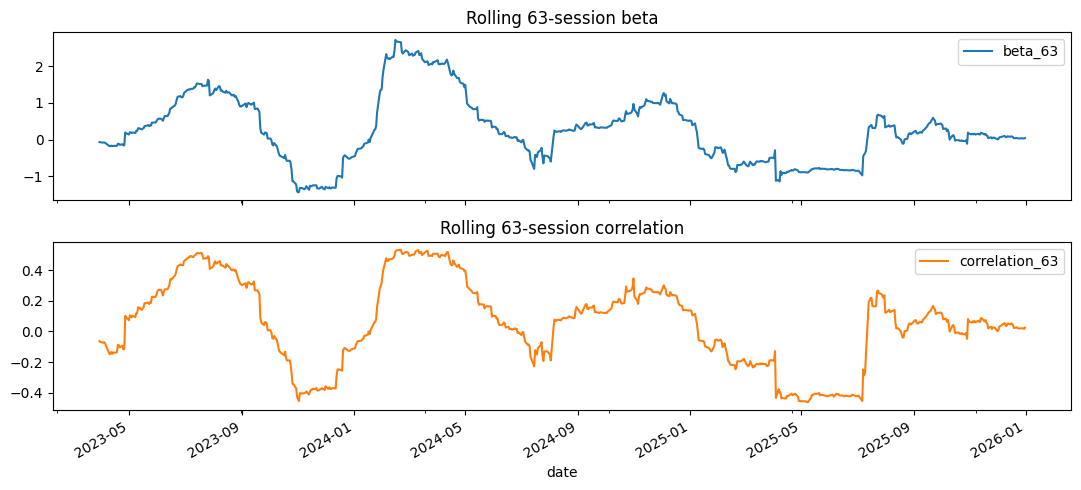

In [4]:
rolling = pd.DataFrame(index=aligned.index)
rolling["beta_63"] = (
    aligned.strategy_excess.rolling(63).cov(aligned.market_excess)
    / aligned.market_excess.rolling(63).var()
)
rolling["correlation_63"] = aligned.strategy_return.rolling(63).corr(
    aligned.market_return
)
save_frame("rolling_market_exposure", rolling)
rolling.plot(
    subplots=True,
    figsize=(11, 5),
    title=["Rolling 63-session beta", "Rolling 63-session correlation"],
)
plt.tight_layout()
plt.show()


## 5. Stress days and relative performance

Use identical aligned dates for the descriptive comparison.


,strategy_return,market_return,rf_daily,strategy_excess,market_excess
date,,,,,
2025-04-04,0.189700,-0.059750,0.000163,0.189537,-0.059912
2025-04-03,-0.015723,-0.048396,0.000163,-0.015886,-0.048559
2025-04-10,0.102029,-0.034608,0.000164,0.101865,-0.034772
2024-08-05,-0.061016,-0.029969,0.000195,-0.061211,-0.030164
2024-12-18,0.013931,-0.029493,0.000165,0.013767,-0.029658
2025-10-10,0.008737,-0.027112,0.000150,0.008587,-0.027262
2025-03-10,0.045101,-0.026973,0.000163,0.044938,-0.027136
2025-04-21,-0.010100,-0.023567,0.000163,-0.010264,-0.023731
2024-07-24,0.026524,-0.023149,0.000200,0.026324,-0.023349


,strategy_return,market_return,rf_daily,strategy_excess,market_excess
date,,,,,
2025-07-22,-0.083617,0.000638,0.000164,-0.083781,0.000473
2024-08-05,-0.061016,-0.029969,0.000195,-0.061211,-0.030164
2024-10-24,-0.053348,0.002146,0.000175,-0.053523,0.001971
2023-12-20,-0.052249,-0.014684,0.000203,-0.052451,-0.014887
2025-04-09,-0.046704,0.095154,0.000162,-0.046867,0.094991
2024-09-11,-0.046536,0.010665,0.000187,-0.046723,0.010478
2024-11-14,-0.046433,-0.006050,0.000171,-0.046603,-0.006220
2024-04-01,-0.046132,-0.002014,0.000201,-0.046333,-0.002215
2024-12-02,-0.044590,0.002448,0.000170,-0.044760,0.002279


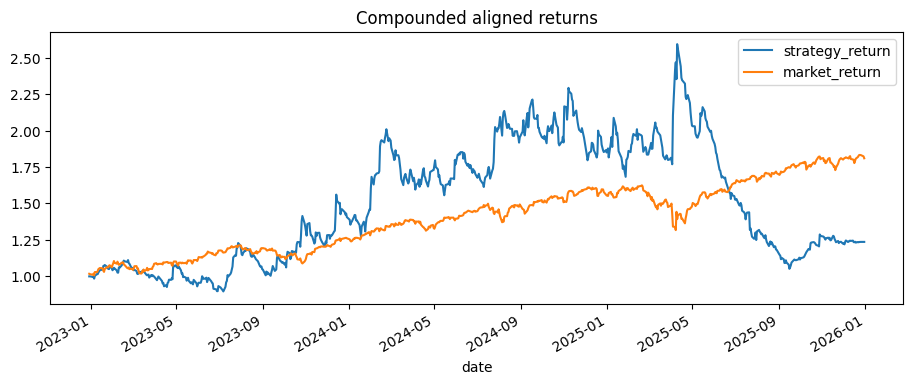

In [5]:
display(aligned.nsmallest(10, "market_return"))
display(aligned.nsmallest(10, "strategy_return"))
(1 + aligned[["strategy_return", "market_return"]]).cumprod().plot(
    figsize=(11, 4), title="Compounded aligned returns"
)
plt.show()


## Save module completion

Wait for this confirmation before moving to the next notebook.


In [6]:
print(f"Completed. Files saved in {OUTPUT_DIR}")


Completed. Files saved in /home/runner/work/Pairs_trading/Pairs_trading/data/processed/current
